In [1]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)

# Kaggle credentials — This is public so it can be run for the assignment, but I need to remove it later!
kaggle_json = '{"username":"owenhursthopf","key":"KGAT_422e00a33a362d2e7ed7b439ced0dc0d"}'

with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(kaggle_json)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('Kaggle credentials configured.')

Kaggle credentials configured.


In [5]:
!kaggle datasets download -d birdy654/cifake-real-and-ai-generated-synthetic-images
!unzip -q cifake-real-and-ai-generated-synthetic-images.zip -d cifake_data
print('Dataset downloaded and extracted.')

'kaggle' is not recognized as an internal or external command,
operable program or batch file.


Dataset downloaded and extracted.


'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
# -------------------------------------------------------
# IMPORTS
# -------------------------------------------------------
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2
from pathlib import Path
from tqdm import tqdm
import random

# TensorFlow / Keras (kept getting an error about not being able to import keras, so I switched to tensorflow.keras)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Scikit-learn metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

I0000 00:00:1778523762.746018    6783 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.21.0
GPU available: True


In [ ]:
# -------------------------------------------------------
# DATASET PATHS
# -------------------------------------------------------
# CIFAKE folder structure: (from kaggle)
#   cifake_data/
#     train/
#       REAL/   (images)
#       FAKE/   (images)
#     test/
#       REAL/
#       FAKE/

DATA_DIR   = Path('cifake')
TRAIN_DIR  = DATA_DIR / 'train'
TEST_DIR   = DATA_DIR / 'test'
IMG_SIZE   = (32, 32)
BATCH_SIZE = 64
SEED       = 42

# Confirm folder structure
for split in ['train', 'test']:
    for label in ['REAL', 'FAKE']: # Loop through each folder and count images
        count = len(list((DATA_DIR / split / label).glob('*.jpg'))) # Count .jpg files in each folder
        print(f'{split}/{label}: {count} images')

train/REAL: 50000 images
train/FAKE: 50000 images
test/REAL: 10000 images
test/FAKE: 10000 images


In [ ]:
# -------------------------------------------------------
# HELPER: Load a flat list of (image_array, label) tuples
# for a given directory split
# -------------------------------------------------------
def load_images_from_split(split_dir, max_per_class=None):
    """Load images as uint8 numpy arrays from a REAL/FAKE folder pair."""
    images, labels = [], []
    for label_idx, label_name in enumerate(['REAL', 'FAKE']): 
        folder = split_dir / label_name
        paths  = sorted(folder.glob('*.jpg'))
        if max_per_class: 
            paths = paths[:max_per_class]
        for p in tqdm(paths, desc=f'Loading {split_dir.name}/{label_name}'): # Show progress bar for each class
            img = cv2.imread(str(p))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR -> RGB
            images.append(img)
            labels.append(label_idx)  # 0=REAL, 1=FAKE
    return np.array(images), np.array(labels)

# Load all 60000 for exploratory analysis
sample_images, sample_labels = load_images_from_split(TRAIN_DIR, max_per_class=60000) # If takes too long to load the following cells, change to 500 for visualization
print(f'Sample shape: {sample_images.shape}, Labels: {sample_labels.shape}')

Loading train/FAKE: 100%|██████████| 50000/50000 [04:41<00:00, 177.65it/s]


Sample shape: (100000, 32, 32, 3), Labels: (100000,)


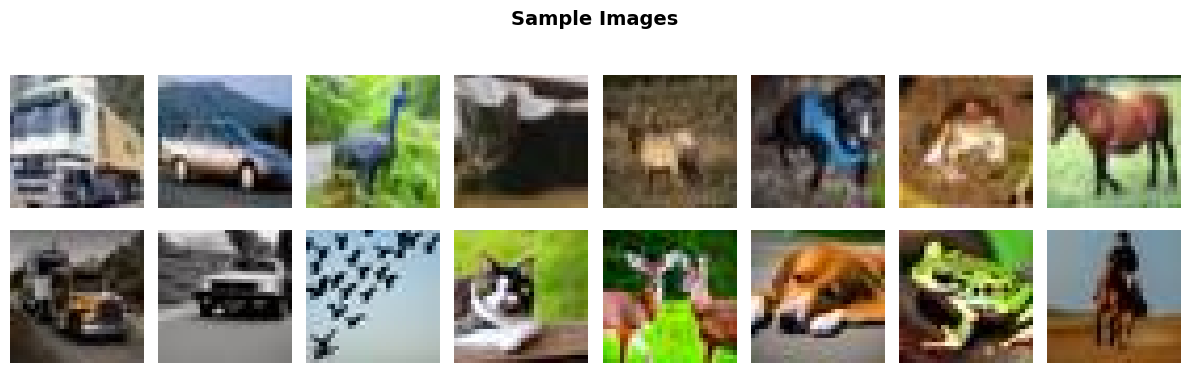

In [4]:
# -------------------------------------------------------
# VISUALIZE: Side-by-side grid of REAL vs FAKE images
# -------------------------------------------------------
def show_sample_grid(images, labels, n=8, title='Sample Images'):
    real_idx = np.where(labels == 0)[0][:n]
    fake_idx = np.where(labels == 1)[0][:n]

    fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 4))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for col, (r, f) in enumerate(zip(real_idx, fake_idx)):
        axes[0, col].imshow(images[r])
        axes[0, col].axis('off')
        if col == 0:
            axes[0, col].set_ylabel('REAL', fontsize=10, rotation=0, labelpad=35)

        axes[1, col].imshow(images[f])
        axes[1, col].axis('off')
        if col == 0:
            axes[1, col].set_ylabel('FAKE', fontsize=10, rotation=0, labelpad=35)

    plt.tight_layout()
    plt.show()

show_sample_grid(sample_images, sample_labels)

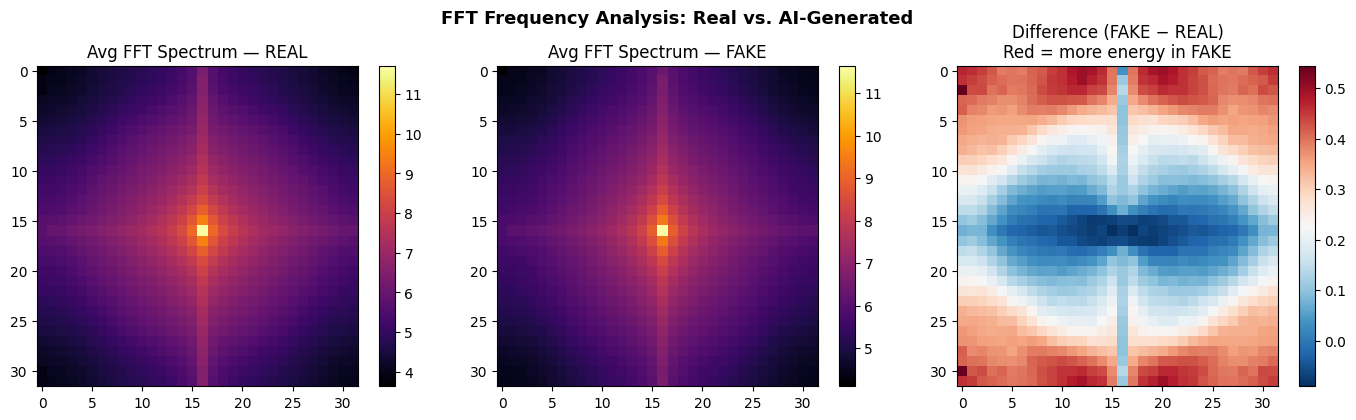

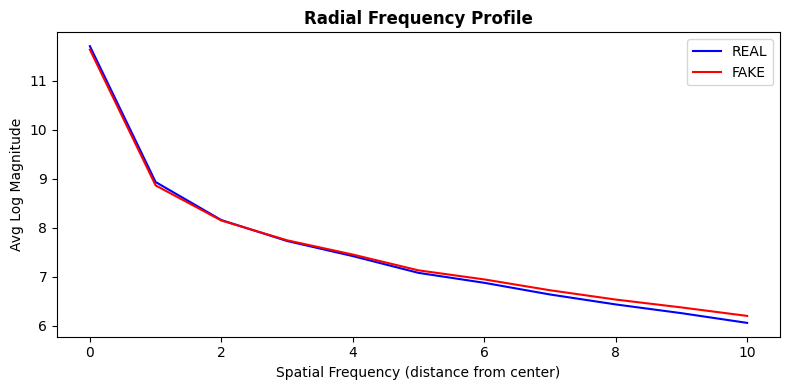

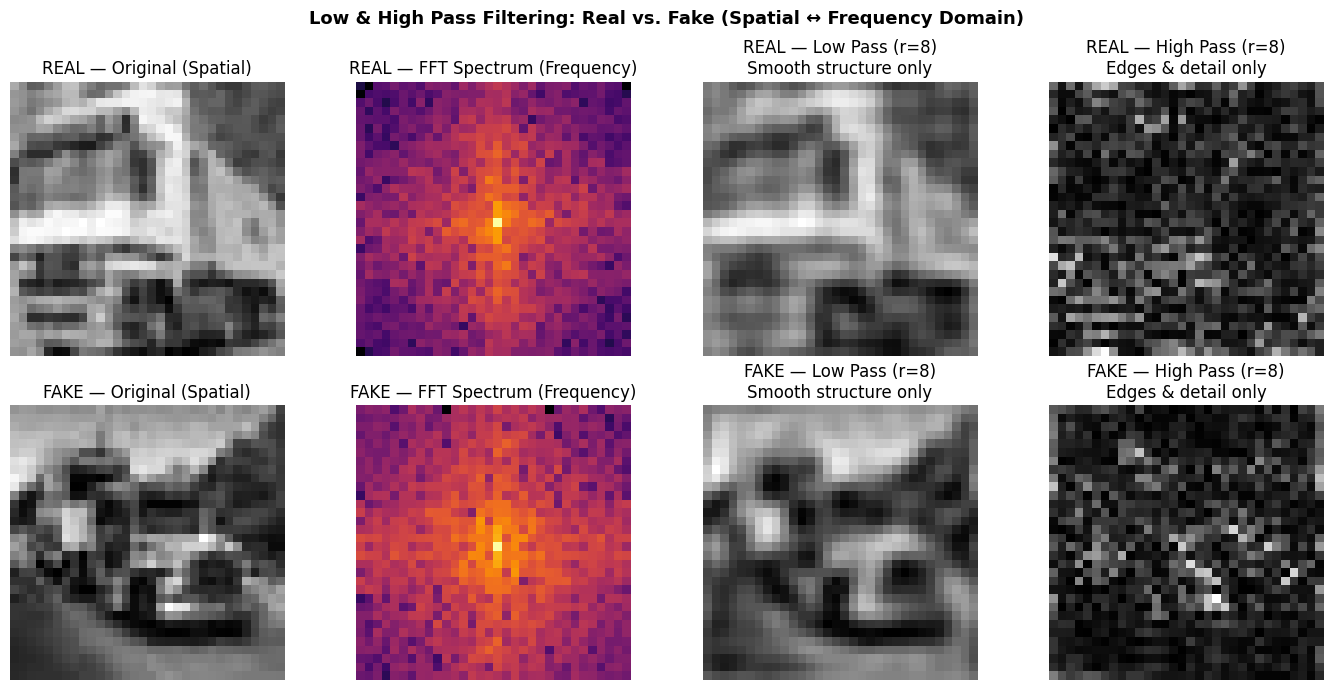

In [6]:
# -------------------------------------------------------
# 3A. FFT FREQUENCY ANALYSIS
# -------------------------------------------------------
# The FFT (Fast Fourier Transform) converts images from the
# spatial domain (pixel values) to the frequency domain,
# where we can analyze and filter different frequency components.
# This is the same Fourier transform covered in class, applied
# to 2D images using numpy's fft2 implementation.

def compute_avg_fft(images):
    """Compute average 2D FFT magnitude spectrum (log scale) for a set of images."""
    spectra = []
    for img in images:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(np.float32)
        fft  = np.fft.fft2(gray)
        fft_shifted = np.fft.fftshift(fft)  # Center low frequencies in the middle
        magnitude   = np.log1p(np.abs(fft_shifted))  # Log scale for visibility
        spectra.append(magnitude)
    return np.mean(spectra, axis=0)

real_images = sample_images[sample_labels == 0]
fake_images = sample_images[sample_labels == 1]

avg_fft_real = compute_avg_fft(real_images)
avg_fft_fake = compute_avg_fft(fake_images)
fft_diff     = avg_fft_fake - avg_fft_real  # Positive = FAKE has more energy there

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('FFT Frequency Analysis: Real vs. AI-Generated', fontsize=13, fontweight='bold')

im0 = axes[0].imshow(avg_fft_real, cmap='inferno')
axes[0].set_title('Avg FFT Spectrum — REAL')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(avg_fft_fake, cmap='inferno')
axes[1].set_title('Avg FFT Spectrum — FAKE')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(fft_diff, cmap='RdBu_r')
axes[2].set_title('Difference (FAKE − REAL)\nRed = more energy in FAKE')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

# Radial frequency profile — 1D summary of energy by spatial frequency
def radial_profile(spectrum):
    """Collapse a 2D spectrum to a 1D radial average (energy vs. distance from center)."""
    cy, cx = np.array(spectrum.shape) // 2
    y, x   = np.indices(spectrum.shape)
    r      = np.sqrt((x - cx)**2 + (y - cy)**2).astype(int)
    profile = np.bincount(r.ravel(), weights=spectrum.ravel()) / np.bincount(r.ravel())
    return profile

r_real = radial_profile(avg_fft_real)
r_fake = radial_profile(avg_fft_fake)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(r_real[:len(r_real)//2], label='REAL', color='blue')
ax.plot(r_fake[:len(r_fake)//2], label='FAKE', color='red')
ax.set_title('Radial Frequency Profile', fontweight='bold')
ax.set_xlabel('Spatial Frequency (distance from center)')
ax.set_ylabel('Avg Log Magnitude')
ax.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# LOW & HIGH PASS FILTERING IN THE FREQUENCY DOMAIN
# -------------------------------------------------------
# By masking regions of the FFT spectrum we can isolate
# low frequencies (smooth structure) or high frequencies
# (edges, noise, fine detail). This demonstrates the full
# spatial -> frequency -> spatial round trip covered in class.

def apply_frequency_filter(img_gray, radius=8, filter_type='high'):
    """
    Apply a circular low-pass or high-pass filter to a grayscale image.
    radius     : cutoff frequency (in pixels from center of spectrum)
    filter_type: 'low' keeps center (smooth), 'high' removes center (edges/detail)
    """
    rows, cols = img_gray.shape
    crow, ccol = rows // 2, cols // 2

    # Transform to frequency domain
    fft         = np.fft.fft2(img_gray.astype(np.float32))
    fft_shifted = np.fft.fftshift(fft)

    # Build circular mask
    mask = np.zeros((rows, cols), np.float32) if filter_type == 'low' else np.ones((rows, cols), np.float32)
    cv2.circle(mask, (ccol, crow), radius, 1 if filter_type == 'low' else 0, -1)

    # Apply mask and invert back to spatial domain
    fft_filtered = fft_shifted * mask
    img_back     = np.fft.ifft2(np.fft.ifftshift(fft_filtered))
    return np.abs(img_back)

# Apply both filters to one example REAL and one example FAKE image
example_real = cv2.cvtColor(real_images[0], cv2.COLOR_RGB2GRAY)
example_fake = cv2.cvtColor(fake_images[0], cv2.COLOR_RGB2GRAY)

RADIUS = 8  # Cutoff frequency — pixels from center of spectrum

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Low & High Pass Filtering: Real vs. Fake (Spatial ↔ Frequency Domain)',
             fontsize=13, fontweight='bold')

row_labels = ['REAL', 'FAKE']
examples   = [example_real, example_fake]

for row, (label, img_gray) in enumerate(zip(row_labels, examples)):
    low_pass  = apply_frequency_filter(img_gray, radius=RADIUS, filter_type='low')
    high_pass = apply_frequency_filter(img_gray, radius=RADIUS, filter_type='high')

    # FFT spectrum of the original (for display)
    fft_display = np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(img_gray.astype(np.float32)))))

    axes[row, 0].imshow(img_gray,   cmap='gray');      axes[row, 0].set_title(f'{label} — Original (Spatial)')
    axes[row, 1].imshow(fft_display, cmap='inferno');  axes[row, 1].set_title(f'{label} — FFT Spectrum (Frequency)')
    axes[row, 2].imshow(low_pass,   cmap='gray');      axes[row, 2].set_title(f'{label} — Low Pass (r={RADIUS})\nSmooth structure only')
    axes[row, 3].imshow(high_pass,  cmap='gray');      axes[row, 3].set_title(f'{label} — High Pass (r={RADIUS})\nEdges & detail only')

    for ax in axes[row]:
        ax.axis('off')

plt.tight_layout()
plt.show()

/tmp/ipykernel_21711/2932848058.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([real_edge_density, fake_edge_density], labels=['REAL', 'FAKE'],


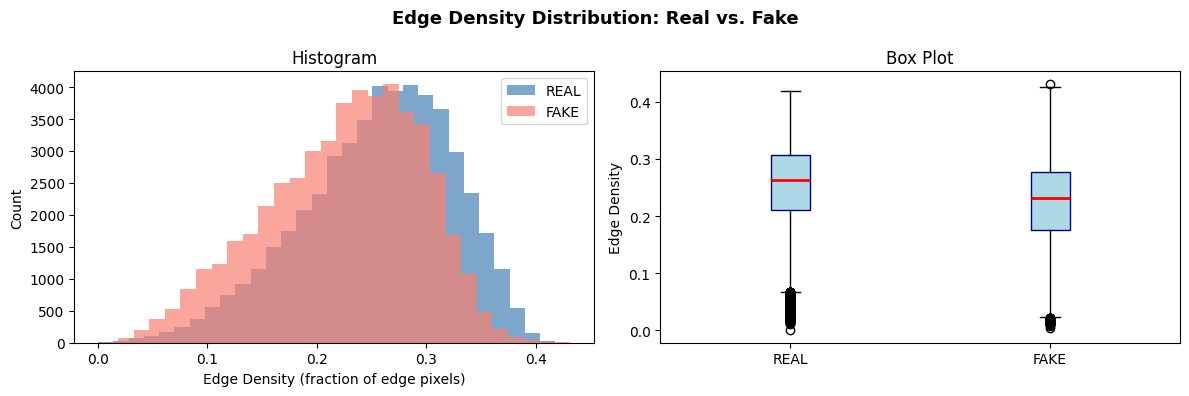

Mean edge density — REAL: 0.2553 | FAKE: 0.2242


In [6]:
# -------------------------------------------------------
# 3B. EDGE DENSITY ANALYSIS
# -------------------------------------------------------
# Compare edge density between real and AI images using
# Canny edge detection. AI images may have smoother or
# more uniform edge distributions.

def compute_edge_density(images, low=50, high=150):
    """Return array of edge pixel densities (fraction of pixels that are edges)."""
    densities = []
    for img in images:
        gray  = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        edges = cv2.Canny(gray, low, high)
        densities.append(np.sum(edges > 0) / edges.size)
    return np.array(densities)

real_edge_density = compute_edge_density(real_images)
fake_edge_density = compute_edge_density(fake_images)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Edge Density Distribution: Real vs. Fake', fontsize=13, fontweight='bold')

axes[0].hist(real_edge_density, bins=30, color='steelblue', alpha=0.7, label='REAL')
axes[0].hist(fake_edge_density, bins=30, color='salmon', alpha=0.7, label='FAKE')
axes[0].set_xlabel('Edge Density (fraction of edge pixels)')
axes[0].set_ylabel('Count')
axes[0].set_title('Histogram')
axes[0].legend()

axes[1].boxplot([real_edge_density, fake_edge_density], labels=['REAL', 'FAKE'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Edge Density')
axes[1].set_title('Box Plot')

plt.tight_layout()
plt.show()

print(f'Mean edge density — REAL: {real_edge_density.mean():.4f} | FAKE: {fake_edge_density.mean():.4f}')

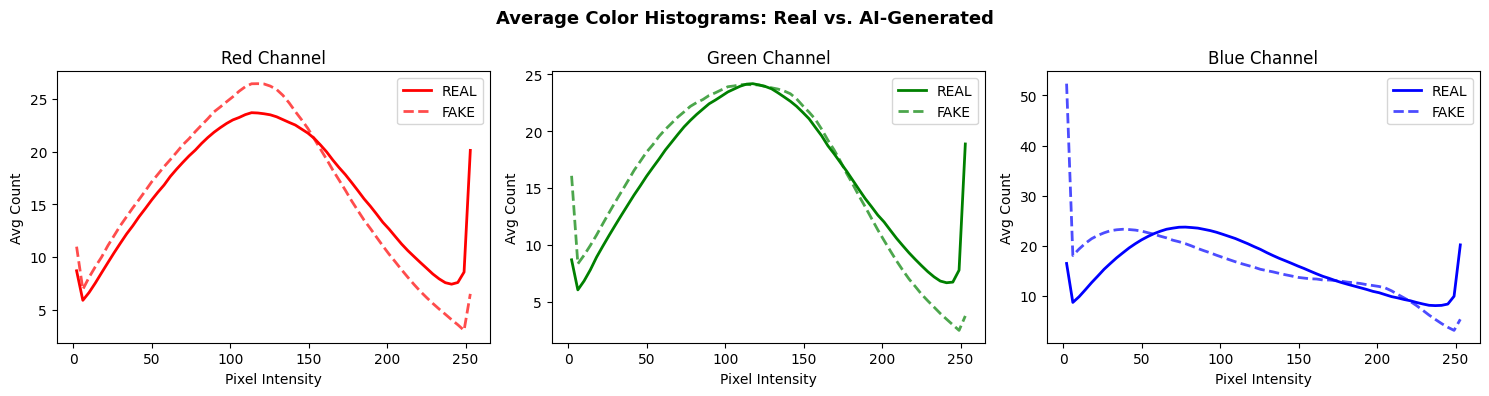

In [7]:
# -------------------------------------------------------
# 3C. COLOR HISTOGRAM ANALYSIS
# -------------------------------------------------------
# Compare average color distributions across RGB channels.
# AI image generators may have biases in color statistics.

def avg_color_histogram(images, bins=64):
    """Compute average per-channel color histogram across images."""
    hist_sum = np.zeros((3, bins))
    for img in images:
        for ch in range(3):
            hist, _ = np.histogram(img[:, :, ch], bins=bins, range=(0, 255))
            hist_sum[ch] += hist
    return hist_sum / len(images)

hist_real = avg_color_histogram(real_images)
hist_fake = avg_color_histogram(fake_images)
channels  = ['Red', 'Green', 'Blue']
colors    = ['red', 'green', 'blue']
bin_edges = np.linspace(0, 255, 65)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Average Color Histograms: Real vs. AI-Generated', fontsize=13, fontweight='bold')

for i, (ch, col) in enumerate(zip(channels, colors)):
    axes[i].plot(bin_centers, hist_real[i], color=col, label='REAL', linewidth=2)
    axes[i].plot(bin_centers, hist_fake[i], color=col, linestyle='--', label='FAKE',
                 linewidth=2, alpha=0.7)
    axes[i].set_title(f'{ch} Channel')
    axes[i].set_xlabel('Pixel Intensity')
    axes[i].set_ylabel('Avg Count')
    axes[i].legend()

plt.tight_layout()
plt.show()

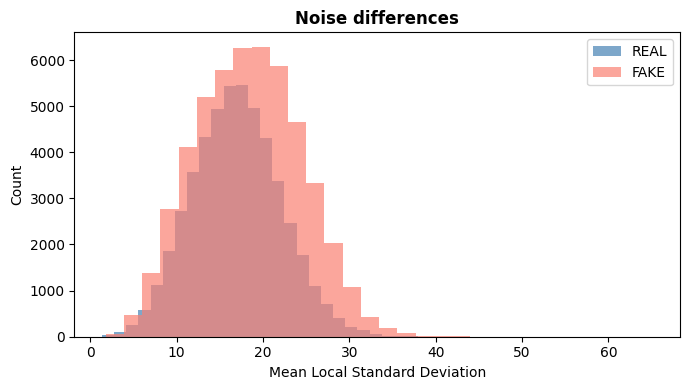

Mean local std — REAL: 16.9413 | FAKE: 18.3829


In [7]:
# -------------------------------------------------------
# 3D. LOCAL NOISE / TEXTURE ANALYSIS
# -------------------------------------------------------
# Compute local standard deviation (a measure of texture/noise)
# for real vs. fake images. AI images are often smoother in
# flat regions and can have characteristic texture patterns.

def mean_local_std(images, kernel=3):
    """Compute mean local standard deviation as a texture roughness measure."""
    stds = []
    for img in images:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(np.float32)
        # Local mean
        k     = np.ones((kernel, kernel), np.float32) / kernel**2
        mean  = cv2.filter2D(gray, -1, k)
        sq_mean = cv2.filter2D(gray**2, -1, k)
        local_var = np.clip(sq_mean - mean**2, 0, None)
        stds.append(np.sqrt(local_var).mean())
    return np.array(stds)

real_noise = mean_local_std(real_images)
fake_noise = mean_local_std(fake_images)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(real_noise, bins=30, color='steelblue', alpha=0.7, label='REAL')
ax.hist(fake_noise, bins=30, color='salmon',    alpha=0.7, label='FAKE')
ax.set_title('Noise differences', fontweight='bold')
ax.set_xlabel('Mean Local Standard Deviation')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Mean local std — REAL: {real_noise.mean():.4f} | FAKE: {fake_noise.mean():.4f}')

# CNN CLASSIFIER

In [15]:
# -------------------------------------------------------
# DATA PIPELINE (tf.data — faster than ImageDataGenerator)
# -------------------------------------------------------
import random

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.1)
    return img, label

def make_dataset(split_dir, augment_data=False, val_split=0.0, split='training', batch_size=64):
    paths, labels = [], []
    for label_idx, label_name in enumerate(['FAKE', 'REAL']):
        folder = split_dir / label_name
        for p in folder.glob('*.jpg'):
            paths.append(str(p))
            labels.append(label_idx)

    combined = list(zip(paths, labels))
    random.shuffle(combined)
    paths, labels = zip(*combined)

    if val_split > 0:
        split_idx = int(len(paths) * (1 - val_split))
        if split == 'training':
            paths, labels = paths[:split_idx], labels[:split_idx]
        else:
            paths, labels = paths[split_idx:], labels[split_idx:]

    dataset = tf.data.Dataset.from_tensor_slices((list(paths), list(labels)))
    dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        dataset = dataset.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset, list(labels)

train_ds, train_labels = make_dataset(TRAIN_DIR, augment_data=True,  val_split=0.15, split='training')
val_ds,   val_labels   = make_dataset(TRAIN_DIR, augment_data=False, val_split=0.15, split='validation')
test_ds,  test_labels  = make_dataset(TEST_DIR,  augment_data=False)

CLASS_NAMES = ['FAKE', 'REAL']
print('Datasets ready.')
print(f'Training samples:   {len(train_labels)}')
print(f'Validation samples: {len(val_labels)}')
print(f'Test samples:       {len(test_labels)}')

Datasets ready.
Training samples:   85000
Validation samples: 15000
Test samples:       20000


In [9]:
# -------------------------------------------------------
# BUILD CUSTOM CNN
# -------------------------------------------------------
# Architecture designed for 32x32 inputs:
#   - 3 convolutional blocks with BatchNorm and MaxPool
#   - Global Average Pooling (more parameter-efficient than Flatten)
#   - Dropout for regularization
#   - Binary output (sigmoid)

def build_custom_cnn(input_shape=(32, 32, 3)):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Classifier head
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')   # Binary output
    ], name='CustomCNN')
    return model

cnn_model = build_custom_cnn()
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()

/home/owenh/cifake_env_wsl/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1778466414.481180   21711 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7533 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:08:00.0, compute capability: 8.6


Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 305,441 (1.17 MB)

 Trainable params: 304,545 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

In [11]:
# Verify GPU is visible to TensorFlow
print("TF version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

# This will print which device each operation runs on during training
tf.debugging.set_log_device_placement(False)  # Set True to see every op's device

# Quick sanity check — run a small computation on GPU
with tf.device('/GPU:0'):
    a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
    b = tf.constant([[5.0, 6.0], [7.0, 8.0]])
    c = tf.matmul(a, b)
    print("Test computation on GPU:", c)
    print("Device used:", c.device)

TF version: 2.21.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Test computation on GPU: tf.Tensor(
[[19. 22.]
 [43. 50.]], shape=(2, 2), dtype=float32)
Device used: /job:localhost/replica:0/task:0/device:GPU:0


In [16]:
# -------------------------------------------------------
# TRAIN CUSTOM CNN
# -------------------------------------------------------
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, verbose=1, min_lr=1e-6),
    ModelCheckpoint('best_cnn.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20


I0000 00:00:1778467738.504507   24521 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_26312__.78


1322/1329 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9349 - loss: 0.1691

I0000 00:00:1778467794.235614   24523 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_26312__.78


1329/1329 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9349 - loss: 0.1691
Epoch 1: val_accuracy improved from None to 0.95013, saving model to best_cnn.keras

Epoch 1: finished saving model to best_cnn.keras
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 69s 47ms/step - accuracy: 0.9381 - loss: 0.1625 - val_accuracy: 0.9501 - val_loss: 0.1252 - learning_rate: 5.0000e-04
Epoch 2/20
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9418 - loss: 0.1503
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 2: val_accuracy did not improve from 0.95013
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 44s 33ms/step - accuracy: 0.9438 - loss: 0.1468 - val_accuracy: 0.9453 - val_loss: 0.1362 - learning_rate: 5.0000e-04
Epoch 3/20
1324/1329 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9495 - loss: 0.1330
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 3: val_accuracy did not improve from 0.95013
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 46s 34ms/step - accuracy:

In [17]:
cnn_model = tf.keras.models.load_model('best_cnn.keras')
print('Model loaded.')

Model loaded.


/home/owenh/cifake_env_wsl/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 30 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


# Model Evaluation

312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step

I0000 00:00:1778469140.902821   24521 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


313/313 ━━━━━━━━━━━━━━━━━━━━ 156s 497ms/step
--- Custom CNN — Test Set Evaluation ---
              precision    recall  f1-score   support

        FAKE       0.98      0.93      0.96     10000
        REAL       0.94      0.98      0.96     10000

    accuracy                           0.96     20000
   macro avg       0.96      0.96      0.96     20000
weighted avg       0.96      0.96      0.96     20000

Overall Accuracy : 0.9575
Overall F1 Score : 0.9585


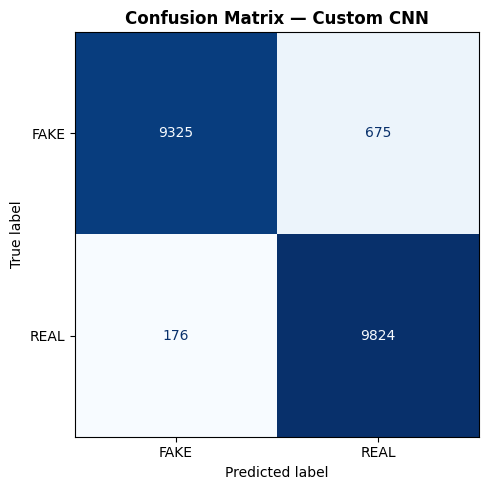

In [18]:
# -------------------------------------------------------
# MODEL EVALUATION ON TEST SET
# -------------------------------------------------------
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score

test_gen.reset()

# Predict on the full test set
y_prob_cnn = cnn_model.predict(test_gen, verbose=1).flatten()
y_pred_cnn = (y_prob_cnn > 0.5).astype(int)
y_true_cnn = test_gen.classes
class_names = list(test_gen.class_indices.keys())  # ['FAKE', 'REAL']

# Classification report (precision, recall, F1 per class)
print('--- Custom CNN — Test Set Evaluation ---')
print(classification_report(y_true_cnn, y_pred_cnn, target_names=class_names))
print(f'Overall Accuracy : {accuracy_score(y_true_cnn, y_pred_cnn):.4f}')
print(f'Overall F1 Score : {f1_score(y_true_cnn, y_pred_cnn):.4f}')

# Confusion matrix
cm   = confusion_matrix(y_true_cnn, y_pred_cnn)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Custom CNN', fontweight='bold')
plt.tight_layout()
plt.show()

Last Conv2D layer: conv2d_5


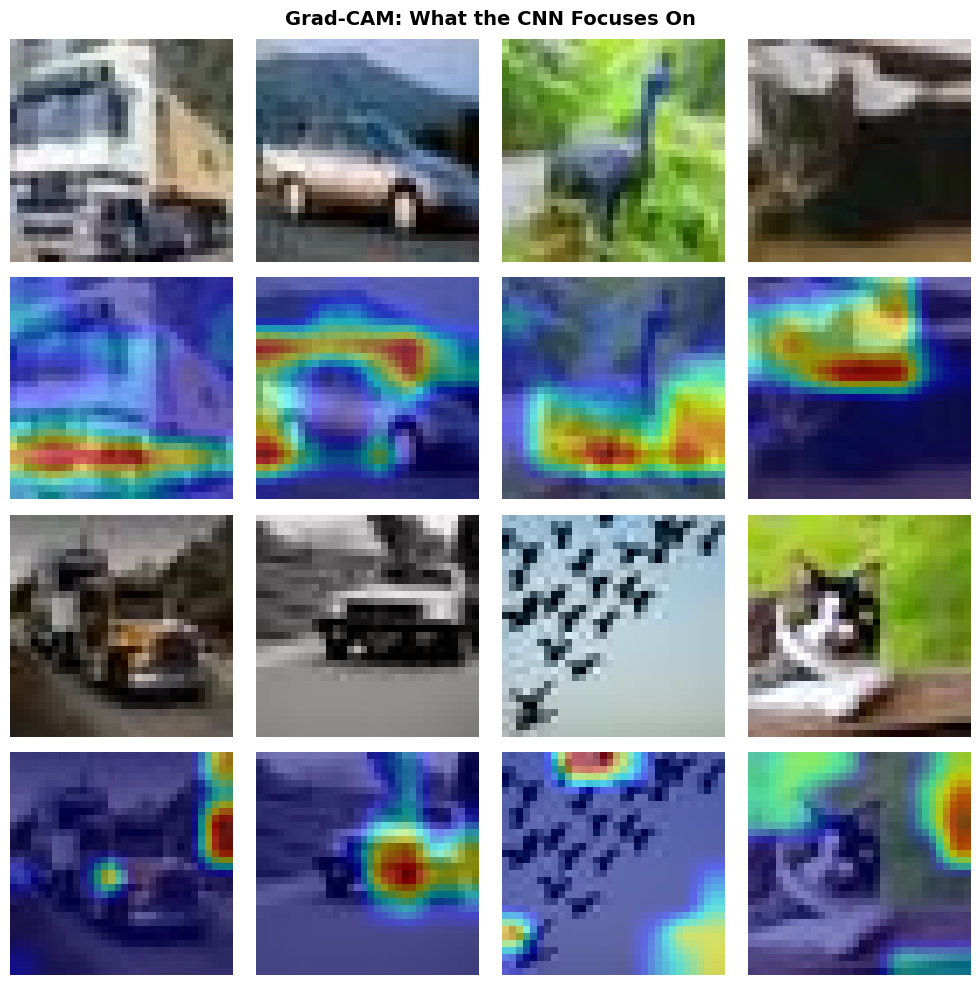

In [19]:
# -------------------------------------------------------
# GRAD-CAM VISUALIZATION
# -------------------------------------------------------
import tensorflow as tf

def get_gradcam_heatmap(model, img_array, last_conv_layer_name):
    """
    Grad-CAM compatible with Keras 3 Sequential models.
    Manually traces through layers and watches the target conv output.
    """
    with tf.GradientTape() as tape:
        x = img_array
        conv_output = None
        for layer in model.layers:
            x = layer(x)
            if layer.name == last_conv_layer_name:
                conv_output = x
                tape.watch(conv_output)  # Watch this tensor for gradient computation
        predictions = x  # Final sigmoid output

        loss = predictions[:, 0]

    grads   = tape.gradient(loss, conv_output)
    pooled  = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_output[0] @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_gradcam(img_uint8, heatmap, alpha=0.5):
    heatmap_resized = cv2.resize(heatmap, (img_uint8.shape[1], img_uint8.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(img_uint8, 1 - alpha, heatmap_colored, alpha, 0)

last_conv = [l.name for l in cnn_model.layers if isinstance(l, layers.Conv2D)][-1]
print(f'Last Conv2D layer: {last_conv}')

n_show = 4
real_imgs_sample = real_images[:n_show]
fake_imgs_sample = fake_images[:n_show]

fig, axes = plt.subplots(4, n_show, figsize=(n_show * 2.5, 10))
row_labels = ['REAL (original)', 'REAL (Grad-CAM)', 'FAKE (original)', 'FAKE (Grad-CAM)']

for col in range(n_show):
    for row_group, imgs in enumerate([real_imgs_sample, fake_imgs_sample]):
        img = imgs[col]
        img_input = np.expand_dims(img.astype(np.float32) / 255.0, axis=0)
        heatmap = get_gradcam_heatmap(cnn_model, img_input, last_conv)
        overlay = overlay_gradcam(img, heatmap)
        base_row = row_group * 2
        axes[base_row,   col].imshow(img);   axes[base_row,   col].axis('off')
        axes[base_row+1, col].imshow(overlay); axes[base_row+1, col].axis('off')

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=9, rotation=0, labelpad=80, va='center')

fig.suptitle('Grad-CAM: What the CNN Focuses On', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

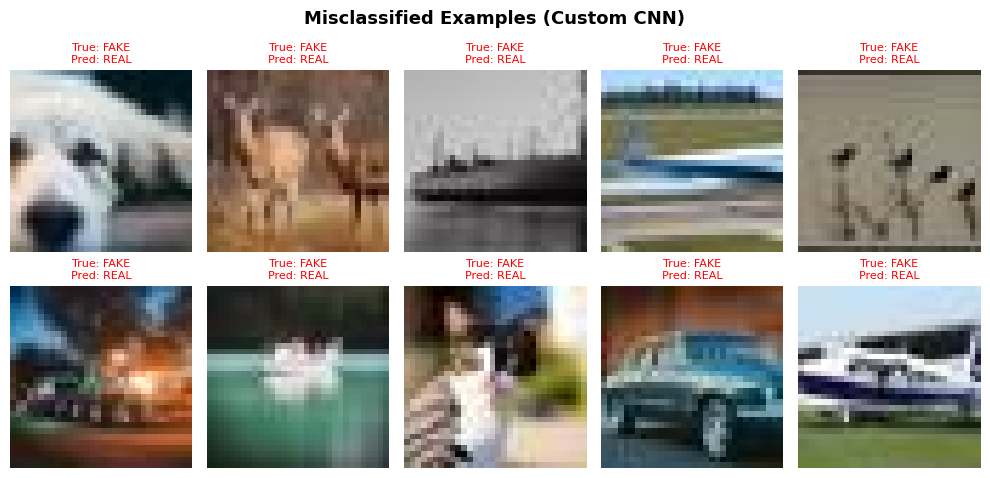

Total misclassified: 851 / 20000 (4.3% error rate)


In [20]:
# -------------------------------------------------------
# VISUALIZE MISCLASSIFIED EXAMPLES
# -------------------------------------------------------
test_gen.reset()
all_images, all_true = [], []
for i in range(len(test_gen)):
    imgs, labels = test_gen[i]
    all_images.extend(imgs)
    all_true.extend(labels.astype(int))

all_images = np.array(all_images)
all_true   = np.array(all_true)

wrong_mask  = y_pred_cnn != all_true
wrong_images = all_images[wrong_mask]
wrong_true   = all_true[wrong_mask]
wrong_pred   = y_pred_cnn[wrong_mask]

n_show = min(10, len(wrong_images))
fig, axes = plt.subplots(2, n_show//2, figsize=(n_show//2 * 2, 5))
fig.suptitle('Misclassified Examples (Custom CNN)', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i in range(n_show):
    axes[i].imshow(wrong_images[i])
    axes[i].axis('off')
    axes[i].set_title(f'True: {class_names[wrong_true[i]]}\nPred: {class_names[wrong_pred[i]]}',
                      fontsize=8, color='red')
plt.tight_layout()
plt.show()
print(f'Total misclassified: {wrong_mask.sum()} / {len(all_true)} ({100*wrong_mask.mean():.1f}% error rate)')

Here it is with the original placeholders restored and 7.2 fixed to match our single-model setup:

---

### 7.1 Classical CV Findings

**FFT Analysis:**
_[Describe what you observed in the frequency domain. Did FAKE images show more/less high-frequency energy? Was the difference concentrated in certain regions of the spectrum?]_

**Edge Density:**
_[Were edges more/less dense in real vs. AI images? What might this suggest about how diffusion models generate images?]_

**Color Histograms:**
_[Did you observe any systematic color biases in AI-generated images?]_

**Texture Roughness:**
_[Were AI images smoother or noisier than real images at the local level?]_

---

### 7.2 CNN Classifier Performance

_[Report your final test accuracy and F1 score. Discuss precision/recall tradeoffs — is the model better at catching FAKE images or REAL ones? Look at the confusion matrix for false positive vs. false negative counts.]_

---

### 7.3 Grad-CAM Insights

_[Describe what the Grad-CAM visualizations revealed. Does the model focus on textures, edges, specific object regions? Is this consistent with the classical CV findings?]_

---

### 7.4 Limitations & Future Work

- The 32×32 resolution limits some classical texture analysis methods that work better on full-resolution images.
- The CIFAKE dataset uses Stable Diffusion — a model trained to detect SD images may not generalize to DALL-E or Midjourney outputs.
- Future work could explore: higher-resolution datasets, ensemble methods, or unsupervised anomaly detection approaches.
- Could also investigate whether adversarial perturbations can fool the classifier (adversarial robustness).

---

### 7.5 Libraries Used

| Library | Purpose |
|---|---|
| `tensorflow` / `keras` | Model building and training |
| `opencv-python` (`cv2`) | Image loading, preprocessing, edge detection, FFT |
| `numpy` | Numerical computation |
| `matplotlib` | Visualization |
| `scikit-learn` | Metrics (confusion matrix, F1, accuracy) |
| `tqdm` | Progress bars |